# Direct ACE Perturbation

This notebook demonstrates `andalus.ace.ACE`, which perturbs an already-processed ACE file's cross sections and nu-bar directly, without reprocessing the underlying ENDF evaluation through NJOY. This gives the same output as `AssimilationSuite.to_ace`, but in a fraction of a second per isotope instead of several minutes, provided a suitable ACE file already exists to start from. Additionally, it assures consistency between the ACE file that was used to obtain the sensitivity coefficients and the calculated response and the perturbed ACE file. As such, differences as the result from processing are kept to a minimum.

Isotope:
- U-235 (ZAID 92235)

### 1. Setup and Imports
We import `andalus` for the `ACE` class, `pandas` to build the adjustment series, `numpy` for array comparisons, and `matplotlib` for visualization.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import andalus

### 2. Reading an ACE File
ACE files are the pointwise cross-section format used by Monte Carlo transport codes such as Serpent and MCNP. Below is a preview of the raw ASCII layout: a header line, a title line, the IZ/AW block, the NXS/JXS directory, and finally the XSS data array.

In [2]:
!head -8 "../data/92235.03c"

 92235.03c  233.024800  2.5852E-08   04/15/26
sandy runs acer                                                          mat9228
      0         0.      0         0.      0         0.      0         0.
      0         0.      0         0.      0         0.      0         0.
      0         0.      0         0.      0         0.      0         0.
      0         0.      0         0.      0         0.      0         0.
  1431107    92235    73699       58       51      641        2        8
        0       92      235        0        0        0        0        0


`ACE.read` parses this layout using the NXS/JXS directory pointers rather than inferring block boundaries from the data, so it works regardless of which reactions are present or how many energy points the grid has.

In [5]:
ace = andalus.ace.ACE.read("../data/92235.03c")
print(ace)

ACE(ZAID=92235, T=2.5852e-08K, NES=73699, MTs=[2, 4, 16, 17, 18, 22, 24, 25, 28, 37, 41, 42, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 102, 103, 107, 203, 207, 444])


Each reaction is available by its MT number and carries its own pointwise cross section and the energy sub-grid it is tabulated on (threshold reactions such as (n,2n) only start above their threshold energy).

In [7]:
fission = ace.reactions[18]  # Fission (MT 18)
capture = ace.reactions[102]  # Radiative capture (MT 102)

print(f"Fission threshold index: {fission.ie}, {len(fission.xs)} points")
print(f"Capture threshold index: {capture.ie}, {len(capture.xs)} points")

Fission threshold index: 1, 73699 points
Capture threshold index: 1, 73699 points


### 3. Perturbing Cross Sections
`ACE.perturb` applies a set of relative multigroup adjustments to the pointwise cross sections. The adjustment is given as a `pandas.Series` indexed by `(MT, E_min_eV, E_max_eV)`, exactly the shape produced by `AssimilationSuite.xs_adjustment` after a GLLS assimilation. Each pointwise energy $E$ is assigned to the bin it falls in using the convention

$$
E_{\min} < E \le E_{\max}
$$

and the cross section at that energy is scaled by $1 + \delta$, where $\delta$ is the bin's relative adjustment. Energies not covered by any bin are left unchanged.

Below we apply a $+50\%$ adjustment to fission (MT 18) and a $-50\%$ adjustment to capture (MT 102), each across the full energy range of the corresponding reaction.

In [8]:
original_fission_xs = fission.xs.copy()
original_capture_xs = capture.xs.copy()

xs_adjustment = pd.Series(
    [0.5, -0.5],
    index=pd.MultiIndex.from_tuples(
        [
            (18, float(fission.energies[0]), float(fission.energies[-1])),
            (102, float(capture.energies[0]), float(capture.energies[-1])),
        ],
        names=["MT", "E_min_eV", "E_max_eV"],
    ),
)
xs_adjustment

MT   E_min_eV      E_max_eV
18   1.000000e-11  30.0        0.5
102  1.000000e-11  30.0       -0.5
dtype: float64

In [9]:
ace.perturb(xs_adjustment)

`ACE.perturb` also propagates each change into `total_xs`, and into `absorption_xs` for reactions that do not emit a secondary neutron. Fission produces secondary neutrons, so its adjustment must reach `total_xs` but must not reach `absorption_xs`; capture is a true disappearance reaction, so its adjustment reaches both.

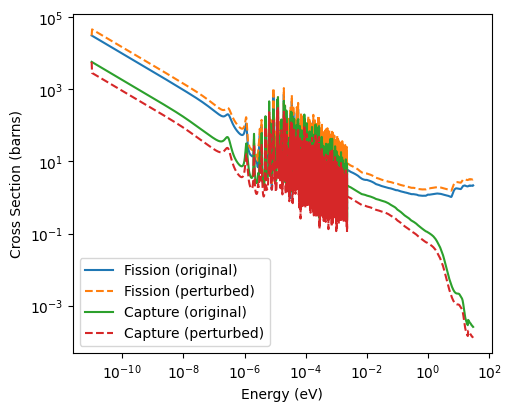

In [10]:
fig, ax1 = plt.subplots(figsize=(5, 4), layout="constrained")
ax1.plot(fission.energies, original_fission_xs, label="Fission (original)")
ax1.plot(fission.energies, fission.xs, label="Fission (perturbed)", ls="--")

ax1.plot(capture.energies, original_capture_xs, label="Capture (original)")
ax1.plot(capture.energies, capture.xs, label="Capture (perturbed)", ls="--")

ax1.set(
    xscale="log",
    yscale="log",
    xlabel="Energy (eV)",
    ylabel="Cross Section (barns)",
)
ax1.legend()
plt.show()

### 4. Perturbing Nu-Bar
Nu-bar, the average number of neutrons released per fission, is stored separately from the reaction cross sections and is perturbed with `ACE.perturb_nu`. It follows the same `(MT, E_min_eV, E_max_eV)` convention, using MT 452 for total nu-bar and MT 456 for prompt nu-bar. Below we apply a $+2\%$ adjustment to total nu-bar across the full energy range.

In [11]:
total_nu = ace.nu["total"]
original_nu_values = total_nu.values.copy()

nu_adjustment = pd.Series(
    [0.02],
    index=pd.MultiIndex.from_tuples(
        [(452, float(total_nu.energy[0]), float(total_nu.energy[-1]))],
        names=["MT", "E_min_eV", "E_max_eV"],
    ),
)
ace.perturb_nu(nu_adjustment)

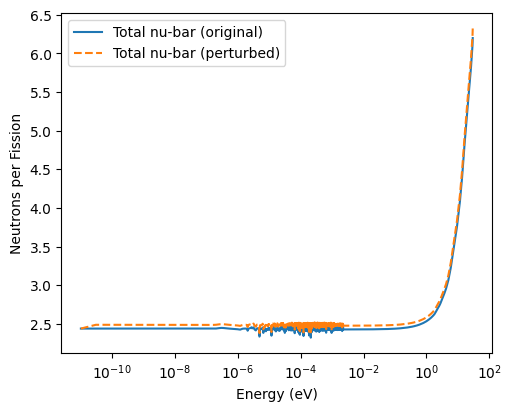

In [12]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.plot(total_nu.energy, original_nu_values, label="Total nu-bar (original)")
ax.plot(total_nu.energy, total_nu.values, label="Total nu-bar (perturbed)", ls="--")
ax.set(
    xscale="log",
    xlabel="Energy (eV)",
    ylabel="Neutrons per Fission",
)
ax.legend()
plt.show()

Prompt nu-bar is stored in a separate table from total nu-bar and is untouched by this adjustment, since only MT 452 was targeted.

In [13]:
print(f"Prompt nu-bar unaffected: {np.allclose(ace.nu['prompt'].values, ace.nu['prompt'].values)}")

Prompt nu-bar unaffected: True


### 5. Writing the Perturbed ACE File
`ACE.write` reconstructs the ASCII ACE file. Entries `perturb`/`perturb_nu` did not change are written back byte for byte from the original file; entries that changed are written in the same scientific-notation format ACE uses for cross-section data. The header, IZ/AW block, and NXS/JXS directory are always reproduced verbatim, since perturbation never touches them.

In [14]:
ace.write("92235_perturbed.03c")

### 6. Verifying the Round Trip
Reading the perturbed file back should reproduce the in-memory values, to the precision of the ACE text format ($\sim 10^{-11}$ relative).

In [15]:
reread = andalus.ace.ACE.read("92235_perturbed.03c")

print(f"Fission xs match:  {np.allclose(reread.reactions[18].xs, ace.reactions[18].xs, rtol=1e-10)}")
print(f"Capture xs match:  {np.allclose(reread.reactions[102].xs, ace.reactions[102].xs, rtol=1e-10)}")
print(f"Total nu-bar match: {np.allclose(reread.nu['total'].values, ace.nu['total'].values, rtol=1e-10)}")
print(f"total_xs match:    {np.allclose(reread.total_xs, ace.total_xs, rtol=1e-10)}")
print(f"absorption_xs match: {np.allclose(reread.absorption_xs, ace.absorption_xs, rtol=1e-10)}")

Fission xs match:  True
Capture xs match:  True
Total nu-bar match: True
total_xs match:    True
absorption_xs match: True


The perturbed ACE file preserves every quantity computed in memory, so it can be used directly in a Monte Carlo transport calculation (for example to verify a GLLS adjustment by rerunning the benchmark set), without ever regenerating the ENDF evaluation through NJOY. `AssimilationSuite.to_ace_direct` applies this workflow automatically across every isotope in a `xs_adjustment` series.

### References
- [ACE format specification](https://github.com/nucleardata/ACEFormat)
- [endf-python](https://github.com/paulromano/endf-python), whose `endf.ace` and `endf.reaction` modules were used as an independent reference to cross-check the NXS/JXS/XSS parsing and per-reaction threshold logic in `andalus.ace`.